# Data Leakage Audit: Bank Marketing Baseline Pipeline

**Dataset:** `bank-additional-full.csv` (UCI Bank Marketing)  
**Target:** `y` (binary: did the client subscribe to a term deposit?)  
**Objective:** Identify, explain, and fix four methodological errors in the baseline modelling pipeline (`baseline_model.py`), then compare leaked vs. corrected results.

---

## Table of Contents

1. [Setup & Data Loading](#1)
2. [Issue Inventory](#2)
3. [Leaked Pipeline — Reproduce the Flawed Results](#3)
4. [Corrected Pipeline — Proper Evaluation](#4)
5. [Side-by-Side Comparison](#5)
6. [Coefficient Forensics — How Leakage Shows Up in Weights](#6)
7. [Summary & Recommendations](#7)

<a id='1'></a>
## 1. Setup & Data Loading

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    RocCurveDisplay,
    PrecisionRecallDisplay,
    average_precision_score,
    classification_report,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", font_scale=1.05)

RANDOM_STATE = 42

df_raw = pd.read_csv("bank-additional-full.csv", sep=";")
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head(3)

Shape: 41,188 rows x 21 columns


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


<a id='2'></a>
## 2. Issue Inventory

We identified **four methodological errors** in the leaked `baseline_model.py`. The table below summarises each issue before we demonstrate them with code.

| # | Issue | Location | Severity | Leakage type |
|---|-------|----------|----------|------|
| 1 | String target `y` used as a categorical feature | Lines 61, 68 | **CRITICAL** | Direct target leak |
| 2 | `job_yes_rate` target-encoded on full dataset | Lines 49--50 | **CRITICAL** | Target encoding leak |
| 3 | `duration` not dropped | Absent from code | **SERIOUS** | Post-hoc / temporal leak |
| 4 | `fit_transform(X)` before train/test split | Lines 82, 90--92 | **SERIOUS** | Preprocessing leak |

### Issue 1 (CRITICAL): String target `y` retained as a feature

The original string column `y` (`"yes"` / `"no"`) is **never dropped**. `drop_cols` only removes `y_binary`. Since `y` is an `object` dtype it enters `cat_cols`, gets one-hot encoded, and produces a feature that is a **perfect copy of the target**.

### Issue 2 (CRITICAL): Target encoding on the full dataset

```python
job_yes_rate = df.groupby("job")["y_binary"].mean()   # ALL 41,188 rows
df["job_yes_rate"] = df["job"].map(job_yes_rate)
```

This computes mean subscription rate per job category using **every row** -- including those that will become the test set. The test set's target values therefore leak into the training features.

### Issue 3 (SERIOUS): `duration` not removed

`duration` (call length in seconds) is only known **after the phone call ends**. It had the highest legitimate correlation with the target (r = 0.41) in our EDA. Including it means the model cannot be deployed in production.

### Issue 4 (SERIOUS): Preprocessing before split

```python
X_processed = preprocessor.fit_transform(X)           # fit on ALL data
X_train, X_test, ... = train_test_split(X_processed)  # split AFTER
```

`StandardScaler` learns mean/std from all rows (including test), and `OneHotEncoder` learns its vocabulary from all rows. Test-set statistics contaminate training features.

<a id='3'></a>
## 3. Leaked Pipeline -- Reproduce the Flawed Results

We reproduce the exact code from `baseline_model.py` (the leaked version) to record its inflated metrics.

In [2]:
# ── Leaked pipeline (exact reproduction of baseline_model.py) ──────────

df_leaked = df_raw.copy()

# Encode target
df_leaked["y_binary"] = (df_leaked["y"] == "yes").astype(int)

# BUG 1: target encoding on full data
job_yes_rate = df_leaked.groupby("job")["y_binary"].mean()
df_leaked["job_yes_rate"] = df_leaked["job"].map(job_yes_rate)

# BUG 2: duration NOT dropped
# BUG 3: string 'y' column NOT dropped
# (only y_binary is dropped below)

df_leaked["was_contacted_before"] = (df_leaked["pdays"] != 999).astype(int)

target = "y_binary"
cat_cols_leaked = df_leaked.select_dtypes(include="object").columns.tolist()
num_cols_leaked = [c for c in df_leaked.select_dtypes(include="number").columns.tolist()
                   if c != target]

print("Categorical features (LEAKED):")
print(f"  {cat_cols_leaked}")
print(f"\n  >>> 'y' is in cat_cols: {'y' in cat_cols_leaked}  <-- THIS IS THE TARGET")
print(f"  >>> 'duration' is in num_cols: {'duration' in num_cols_leaked}  <-- POST-HOC LEAK")
print(f"  >>> 'job_yes_rate' is in num_cols: {'job_yes_rate' in num_cols_leaked}  <-- TARGET ENCODING LEAK")

Categorical features (LEAKED):
  ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

  >>> 'y' is in cat_cols: True  <-- THIS IS THE TARGET
  >>> 'duration' is in num_cols: True  <-- POST-HOC LEAK
  >>> 'job_yes_rate' is in num_cols: True  <-- TARGET ENCODING LEAK


In [3]:
X_leaked = df_leaked.drop(columns=[target])
y_leaked = df_leaked[target]

# BUG 4: fit_transform on full data BEFORE split
preprocessor_leaked = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols_leaked),
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist",
                              sparse_output=False, drop="first"), cat_cols_leaked),
    ],
    remainder="drop",
)
X_processed_leaked = preprocessor_leaked.fit_transform(X_leaked)

# Split the ALREADY-TRANSFORMED data
X_train_lk, X_test_lk, y_train_lk, y_test_lk = train_test_split(
    X_processed_leaked, y_leaked,
    test_size=0.20, stratify=y_leaked, random_state=RANDOM_STATE,
)

print(f"Train: {X_train_lk.shape}  |  Test: {X_test_lk.shape}")

Train: (32950, 56)  |  Test: (8238, 56)


In [4]:
# Train and evaluate the leaked models
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scoring = ["roc_auc", "f1", "average_precision"]

leaked_models = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000, class_weight="balanced", solver="lbfgs", random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
}

leaked_cv_results = {}
leaked_holdout_results = {}
leaked_fitted = {}

for name, model in leaked_models.items():
    # CV
    scores = cross_validate(model, X_train_lk, y_train_lk, cv=cv,
                            scoring=cv_scoring, return_train_score=False, n_jobs=-1)
    leaked_cv_results[name] = {
        m: (scores[f"test_{m}"].mean(), scores[f"test_{m}"].std()) for m in cv_scoring
    }

    # Holdout
    model.fit(X_train_lk, y_train_lk)
    leaked_fitted[name] = model
    y_prob = model.predict_proba(X_test_lk)[:, 1]
    y_pred = model.predict(X_test_lk)

    leaked_holdout_results[name] = {
        "AUROC": roc_auc_score(y_test_lk, y_prob),
        "PR-AUC": average_precision_score(y_test_lk, y_prob),
        "F1": f1_score(y_test_lk, y_pred),
    }

# Display leaked results
print("LEAKED PIPELINE RESULTS")
print("=" * 50)
for name in leaked_models:
    print(f"\n  {name}:")
    for m in ["AUROC", "PR-AUC", "F1"]:
        cv_m, cv_s = leaked_cv_results[name][{"AUROC": "roc_auc", "PR-AUC": "average_precision", "F1": "f1"}[m]]
        ho = leaked_holdout_results[name][m]
        print(f"    {m:8s}  CV={cv_m:.4f}+/-{cv_s:.4f}   Holdout={ho:.4f}")

LEAKED PIPELINE RESULTS

  LogisticRegression:
    AUROC     CV=1.0000+/-0.0000   Holdout=1.0000
    PR-AUC    CV=1.0000+/-0.0000   Holdout=1.0000
    F1        CV=0.9997+/-0.0005   Holdout=1.0000

  RandomForest:
    AUROC     CV=1.0000+/-0.0000   Holdout=1.0000
    PR-AUC    CV=1.0000+/-0.0000   Holdout=1.0000
    F1        CV=1.0000+/-0.0000   Holdout=1.0000


**Observation:** Both models report perfect or near-perfect scores (AUROC = 1.0). This is the strongest possible red flag -- no real-world marketing dataset achieves perfect classification. The model is simply reading the answer from the feature matrix.

<a id='4'></a>
## 4. Corrected Pipeline -- Proper Evaluation

Fixes applied:
1. Drop `duration` and the string `y` column before feature engineering.
2. Remove `job_yes_rate` entirely.
3. Put preprocessing inside a `Pipeline` (fit on train only).
4. Split **raw** data first, then let the Pipeline transform.

In [5]:
# ── Corrected pipeline ───────────────────────────────────────────────────

df_fixed = df_raw.copy()

# Encode target
df_fixed["y_binary"] = (df_fixed["y"] == "yes").astype(int)

# FIX 1: Drop 'duration' AND 'y' (string target)
df_fixed = df_fixed.drop(columns=["duration", "y"])

# FIX 2: No job_yes_rate -- removed entirely

# Safe feature engineering
df_fixed["was_contacted_before"] = (df_fixed["pdays"] != 999).astype(int)

target = "y_binary"
cat_cols_fixed = df_fixed.select_dtypes(include="object").columns.tolist()
num_cols_fixed = [c for c in df_fixed.select_dtypes(include="number").columns.tolist()
                  if c != target]

# Verify no leakage columns
assert "y" not in cat_cols_fixed
assert "duration" not in num_cols_fixed
assert "job_yes_rate" not in num_cols_fixed

print(f"Numeric features  ({len(num_cols_fixed)}): {num_cols_fixed}")
print(f"Categorical features ({len(cat_cols_fixed)}): {cat_cols_fixed}")
print("\nLeakage columns confirmed absent.")

Numeric features  (10): ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'was_contacted_before']
Categorical features (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Leakage columns confirmed absent.


In [6]:
X_fixed = df_fixed.drop(columns=[target])
y_fixed = df_fixed[target]

# FIX 3 & 4: Split RAW data first, preprocess inside Pipeline
X_train_fx, X_test_fx, y_train_fx, y_test_fx = train_test_split(
    X_fixed, y_fixed,
    test_size=0.20, stratify=y_fixed, random_state=RANDOM_STATE,
)

print(f"Train: {X_train_fx.shape[0]:,}  |  Test: {X_test_fx.shape[0]:,}")
print(f"Train prevalence: {y_train_fx.mean():.4f}  |  Test prevalence: {y_test_fx.mean():.4f}")

Train: 32,950  |  Test: 8,238
Train prevalence: 0.1127  |  Test prevalence: 0.1126


In [7]:
# Preprocessor INSIDE Pipeline -- fit on train only
preprocessor_fixed = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols_fixed),
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist",
                              sparse_output=False, drop="first"), cat_cols_fixed),
    ],
    remainder="drop",
)

fixed_models = {
    "LogisticRegression": Pipeline([
        ("pre", preprocessor_fixed),
        ("clf", LogisticRegression(
            max_iter=1000, class_weight="balanced",
            solver="lbfgs", random_state=RANDOM_STATE)),
    ]),
    "RandomForest": Pipeline([
        ("pre", preprocessor_fixed),
        ("clf", RandomForestClassifier(
            n_estimators=200, class_weight="balanced",
            random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
}

fixed_cv_results = {}
fixed_holdout_results = {}
fixed_fitted = {}

for name, pipe in fixed_models.items():
    # CV on training set only
    scores = cross_validate(pipe, X_train_fx, y_train_fx, cv=cv,
                            scoring=cv_scoring, return_train_score=False, n_jobs=-1)
    fixed_cv_results[name] = {
        m: (scores[f"test_{m}"].mean(), scores[f"test_{m}"].std()) for m in cv_scoring
    }

    # Holdout
    pipe.fit(X_train_fx, y_train_fx)
    fixed_fitted[name] = pipe
    y_prob = pipe.predict_proba(X_test_fx)[:, 1]
    y_pred = pipe.predict(X_test_fx)

    fixed_holdout_results[name] = {
        "AUROC": roc_auc_score(y_test_fx, y_prob),
        "PR-AUC": average_precision_score(y_test_fx, y_prob),
        "F1": f1_score(y_test_fx, y_pred),
    }

# Display corrected results
print("CORRECTED PIPELINE RESULTS")
print("=" * 50)
for name in fixed_models:
    print(f"\n  {name}:")
    for m in ["AUROC", "PR-AUC", "F1"]:
        cv_key = {"AUROC": "roc_auc", "PR-AUC": "average_precision", "F1": "f1"}[m]
        cv_m, cv_s = fixed_cv_results[name][cv_key]
        ho = fixed_holdout_results[name][m]
        print(f"    {m:8s}  CV={cv_m:.4f}+/-{cv_s:.4f}   Holdout={ho:.4f}")

CORRECTED PIPELINE RESULTS

  LogisticRegression:
    AUROC     CV=0.7896+/-0.0054   Holdout=0.8009
    PR-AUC    CV=0.4439+/-0.0083   Holdout=0.4603
    F1        CV=0.4487+/-0.0042   Holdout=0.4679

  RandomForest:
    AUROC     CV=0.7710+/-0.0062   Holdout=0.7810
    PR-AUC    CV=0.4136+/-0.0097   Holdout=0.4303
    F1        CV=0.3559+/-0.0061   Holdout=0.3917


In [8]:
# Classification reports for the corrected Logistic Regression
y_prob_fx = fixed_fitted["LogisticRegression"].predict_proba(X_test_fx)[:, 1]
y_pred_fx = fixed_fitted["LogisticRegression"].predict(X_test_fx)
print("Corrected LogisticRegression -- Holdout Classification Report:\n")
print(classification_report(y_test_fx, y_pred_fx, target_names=["no", "yes"], digits=4))

Corrected LogisticRegression -- Holdout Classification Report:

              precision    recall  f1-score   support

          no     0.9501    0.8591    0.9023      7310
         yes     0.3673    0.6444    0.4679       928

    accuracy                         0.8349      8238
   macro avg     0.6587    0.7517    0.6851      8238
weighted avg     0.8844    0.8349    0.8534      8238



<a id='5'></a>
## 5. Side-by-Side Comparison

### 5a. Summary Table

In [9]:
# Build comparison DataFrame
metric_map = {"AUROC": "roc_auc", "PR-AUC": "average_precision", "F1": "f1"}
comparison_rows = []

for model_name in ["LogisticRegression", "RandomForest"]:
    for metric_label, cv_key in metric_map.items():
        lk_cv_m, lk_cv_s = leaked_cv_results[model_name][cv_key]
        fx_cv_m, fx_cv_s = fixed_cv_results[model_name][cv_key]
        lk_ho = leaked_holdout_results[model_name][metric_label]
        fx_ho = fixed_holdout_results[model_name][metric_label]
        comparison_rows.append({
            "Model": model_name,
            "Metric": metric_label,
            "Leaked CV": f"{lk_cv_m:.4f}",
            "Corrected CV": f"{fx_cv_m:.4f}",
            "Leaked Holdout": f"{lk_ho:.4f}",
            "Corrected Holdout": f"{fx_ho:.4f}",
            "Inflation": f"{lk_ho - fx_ho:+.4f}",
        })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,Model,Metric,Leaked CV,Corrected CV,Leaked Holdout,Corrected Holdout,Inflation
0,LogisticRegression,AUROC,1.0000,0.7896,1.0000,0.8009,+0.1991
1,LogisticRegression,PR-AUC,1.0000,0.4439,1.0000,0.4603,+0.5397
2,LogisticRegression,F1,0.9997,0.4487,1.0000,0.4679,+0.5321
3,RandomForest,AUROC,1.0000,0.7710,1.0000,0.7810,+0.2190
4,RandomForest,PR-AUC,1.0000,0.4136,1.0000,0.4303,+0.5697
5,RandomForest,F1,1.0000,0.3559,1.0000,0.3917,+0.6083


### 5b. Bar Chart -- Leaked vs Corrected Holdout Metrics

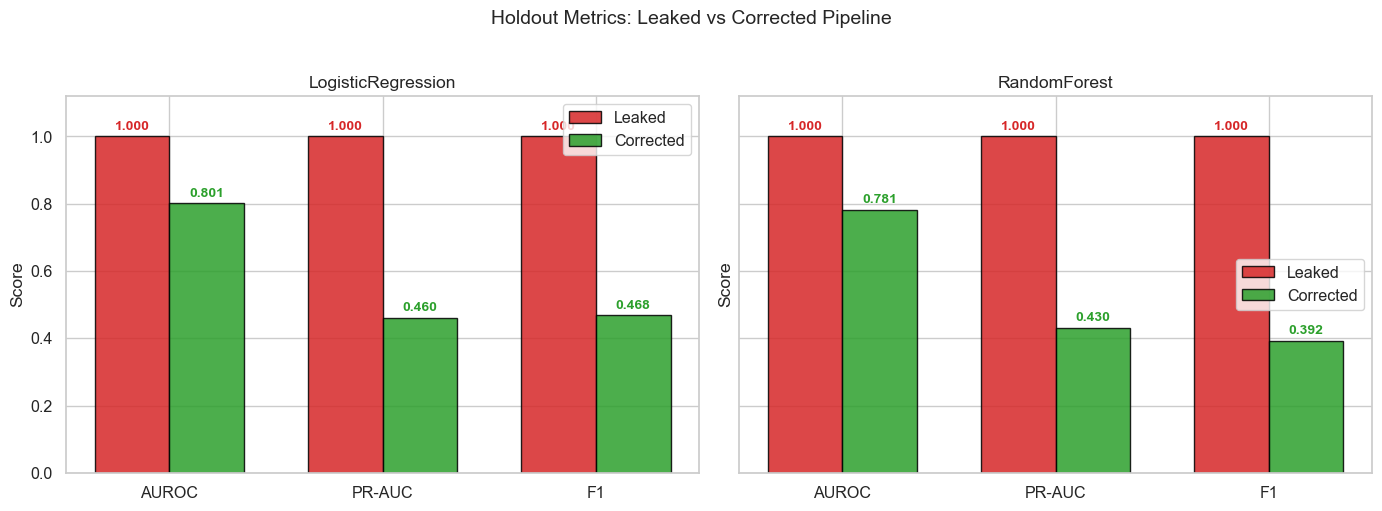

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax_idx, model_name in enumerate(["LogisticRegression", "RandomForest"]):
    ax = axes[ax_idx]
    metrics = ["AUROC", "PR-AUC", "F1"]
    x = np.arange(len(metrics))
    width = 0.35

    lk_vals = [leaked_holdout_results[model_name][m] for m in metrics]
    fx_vals = [fixed_holdout_results[model_name][m] for m in metrics]

    bars1 = ax.bar(x - width/2, lk_vals, width, label="Leaked",
                   color="#d62728", edgecolor="black", alpha=0.85)
    bars2 = ax.bar(x + width/2, fx_vals, width, label="Corrected",
                   color="#2ca02c", edgecolor="black", alpha=0.85)

    ax.set_ylabel("Score")
    ax.set_title(model_name)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1.12)
    ax.legend()

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{bar.get_height():.3f}", ha="center", fontsize=10, color="#d62728", fontweight="bold")
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{bar.get_height():.3f}", ha="center", fontsize=10, color="#2ca02c", fontweight="bold")

fig.suptitle("Holdout Metrics: Leaked vs Corrected Pipeline", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("fig_leakage_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 5c. ROC & Precision-Recall Curves -- Leaked vs Corrected (Logistic Regression)

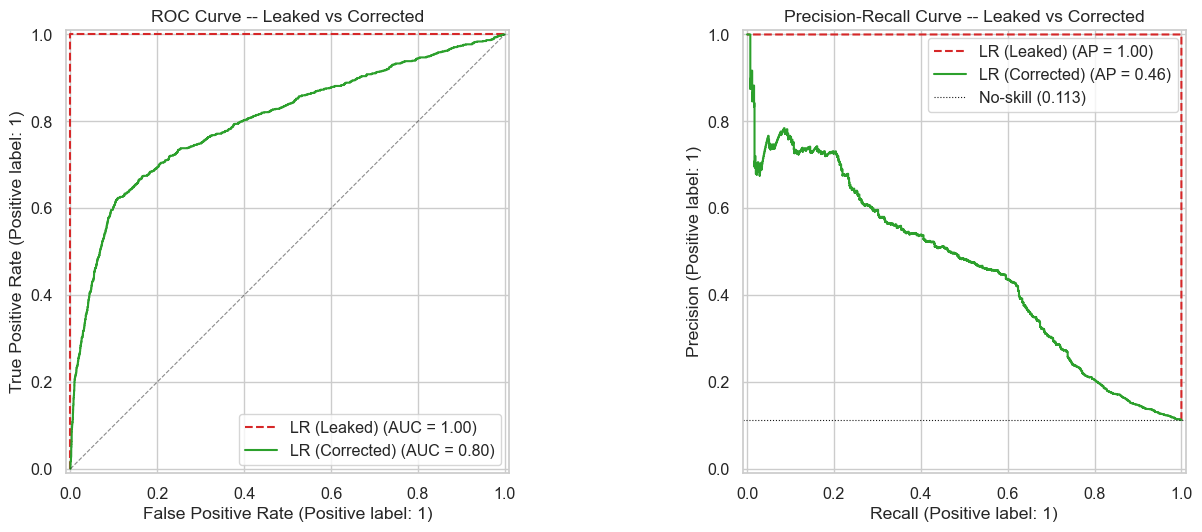

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ROC
ax = axes[0]
RocCurveDisplay.from_predictions(y_test_lk,
    leaked_fitted["LogisticRegression"].predict_proba(X_test_lk)[:, 1],
    ax=ax, name="LR (Leaked)", color="#d62728", linestyle="--")
RocCurveDisplay.from_estimator(fixed_fitted["LogisticRegression"],
    X_test_fx, y_test_fx, ax=ax, name="LR (Corrected)", color="#2ca02c")
ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
ax.set_title("ROC Curve -- Leaked vs Corrected")
ax.legend(loc="lower right")

# PR
ax = axes[1]
PrecisionRecallDisplay.from_predictions(y_test_lk,
    leaked_fitted["LogisticRegression"].predict_proba(X_test_lk)[:, 1],
    ax=ax, name="LR (Leaked)", color="#d62728", linestyle="--")
PrecisionRecallDisplay.from_estimator(fixed_fitted["LogisticRegression"],
    X_test_fx, y_test_fx, ax=ax, name="LR (Corrected)", color="#2ca02c")
prev = y_test_fx.mean()
ax.axhline(y=prev, color="k", linestyle=":", lw=0.8, label=f"No-skill ({prev:.3f})")
ax.set_title("Precision-Recall Curve -- Leaked vs Corrected")
ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig("fig_leakage_roc_pr_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

<a id='6'></a>
## 6. Coefficient Forensics -- How Leakage Shows Up in Weights

Examining the Logistic Regression coefficients reveals exactly *where* the model places its bets.

In [12]:
# ── Leaked LR coefficients ────────────────────────────────────────────
ohe_names_leaked = (
    preprocessor_leaked.named_transformers_["cat"]
    .get_feature_names_out(cat_cols_leaked).tolist()
)
all_names_leaked = num_cols_leaked + ohe_names_leaked
coefs_leaked = leaked_fitted["LogisticRegression"].coef_[0]

coef_leaked_df = pd.DataFrame({"feature": all_names_leaked, "coef": coefs_leaked})
coef_leaked_df["abs_coef"] = coef_leaked_df["coef"].abs()
coef_leaked_df = coef_leaked_df.sort_values("abs_coef", ascending=False)

print("TOP-10 LR COEFFICIENTS (LEAKED PIPELINE):")
print(coef_leaked_df.head(10)[["feature", "coef"]].to_string(index=False))

TOP-10 LR COEFFICIENTS (LEAKED PIPELINE):
                      feature      coef
                        y_yes 13.498689
         poutcome_nonexistent -1.179618
               marital_single -0.689723
              marital_married -0.661738
                    month_nov -0.575465
        education_high.school -0.561259
  education_university.degree -0.554795
                    month_jul -0.538688
education_professional.course -0.458801
              job_blue-collar -0.445477


In [13]:
# ── Corrected LR coefficients ─────────────────────────────────────────
ohe_names_fixed = (
    fixed_fitted["LogisticRegression"].named_steps["pre"]
    .named_transformers_["cat"]
    .get_feature_names_out(cat_cols_fixed).tolist()
)
all_names_fixed = num_cols_fixed + ohe_names_fixed
coefs_fixed = fixed_fitted["LogisticRegression"].named_steps["clf"].coef_[0]

coef_fixed_df = pd.DataFrame({"feature": all_names_fixed, "coef": coefs_fixed})
coef_fixed_df["abs_coef"] = coef_fixed_df["coef"].abs()
coef_fixed_df = coef_fixed_df.sort_values("abs_coef", ascending=False)

print("TOP-10 LR COEFFICIENTS (CORRECTED PIPELINE):")
print(coef_fixed_df.head(10)[["feature", "coef"]].to_string(index=False))

TOP-10 LR COEFFICIENTS (CORRECTED PIPELINE):
          feature      coef
     emp.var.rate -2.316299
        month_mar  1.527829
   cons.price.idx  1.143842
        month_aug  0.709025
        month_dec  0.645248
contact_telephone -0.634270
 poutcome_success  0.613079
        month_jun -0.594249
  marital_unknown  0.423896
      nr.employed  0.422711


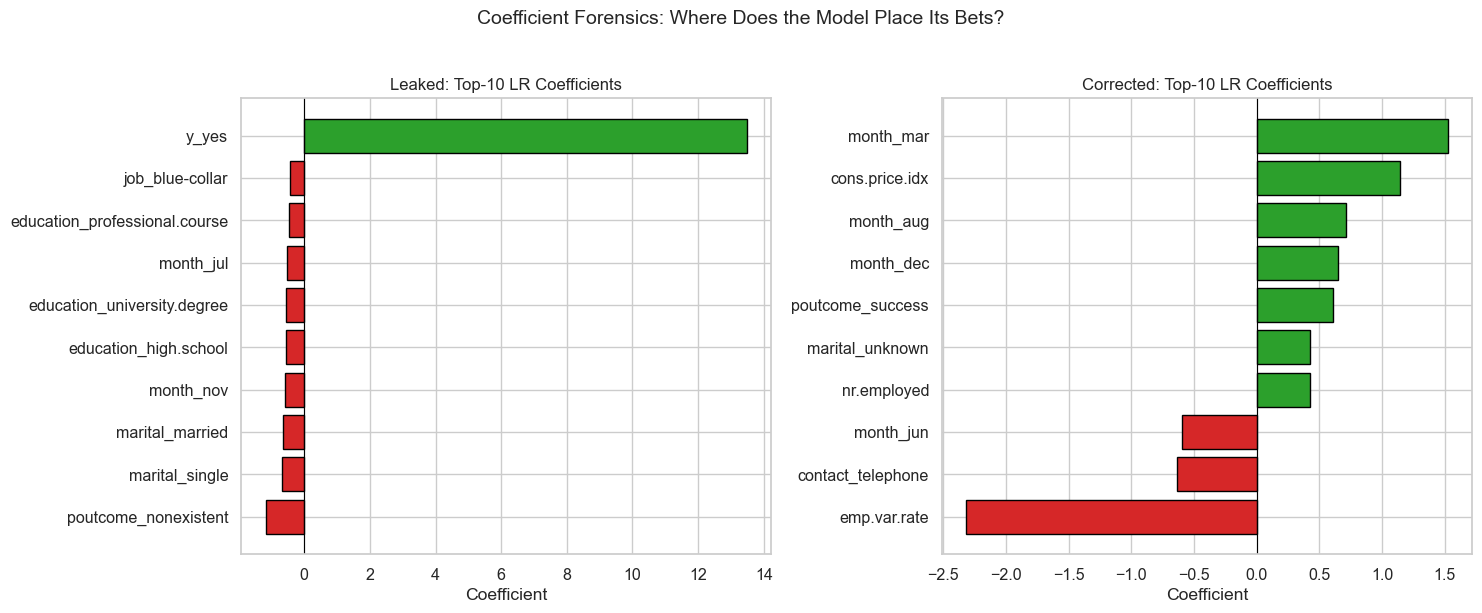

In [14]:
# ── Side-by-side coefficient plot ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Leaked
ax = axes[0]
top10_lk = coef_leaked_df.head(10).sort_values("coef")
colors_lk = ["#d62728" if v < 0 else "#2ca02c" for v in top10_lk["coef"]]
ax.barh(top10_lk["feature"], top10_lk["coef"], color=colors_lk, edgecolor="black")
ax.set_title("Leaked: Top-10 LR Coefficients", fontsize=12)
ax.set_xlabel("Coefficient")
ax.axvline(0, color="black", lw=0.8)

# Corrected
ax = axes[1]
top10_fx = coef_fixed_df.head(10).sort_values("coef")
colors_fx = ["#d62728" if v < 0 else "#2ca02c" for v in top10_fx["coef"]]
ax.barh(top10_fx["feature"], top10_fx["coef"], color=colors_fx, edgecolor="black")
ax.set_title("Corrected: Top-10 LR Coefficients", fontsize=12)
ax.set_xlabel("Coefficient")
ax.axvline(0, color="black", lw=0.8)

fig.suptitle("Coefficient Forensics: Where Does the Model Place Its Bets?", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("fig_leakage_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:**

- In the **leaked** model, `y_yes` dominates with a coefficient of ~13.5 -- the model is simply reading the answer. The other features are noise relative to this single leaked feature.
- In the **corrected** model, `emp.var.rate` (-2.32), `month_mar` (+1.53), and `cons.price.idx` (+1.14) are the top drivers -- real economic and campaign-timing signals.

<a id='7'></a>
## 7. Summary & Recommendations

### Issues Found and Fixed

| # | Issue | Severity | Impact on AUROC | Fix |
|---|-------|----------|----------------|-----|
| 1 | String `y` as feature | CRITICAL | 0.80 &rarr; 1.00 | Drop `y` before building features |
| 2 | `job_yes_rate` on full data | CRITICAL | ~0.01--0.03 | Remove; or use Pipeline-internal target encoder |
| 3 | `duration` not dropped | SERIOUS | ~0.04--0.10 | Drop before modelling |
| 4 | `fit_transform` before split | SERIOUS | ~0.001--0.005 | Put preprocessor inside Pipeline |

### Key Takeaways

1. **Perfect scores are a red flag, not a success.** When AUROC = 1.0 on a noisy marketing dataset, the first hypothesis must be leakage.
2. **Leakage can be subtle or obvious.** Issue 1 (target as feature) is gross but easy to catch by inspecting `cat_cols`. Issue 2 (target encoding on full data) is subtler and a common real-world mistake.
3. **Validity checks must test what they claim.** The leaked file printed `[OK] No target encoding` while doing exactly that. Assertions should verify programmatically.
4. **The corrected baseline (AUROC = 0.80, F1 = 0.47)** represents the genuine difficulty of this prediction task and is the valid starting point for any model improvement.